# LLM Reasoning Evaluation on GSM8K: No-CoT vs Chain-of-Thought vs Self-Consistency

**The problem.** A team is evaluating a small instruction-tuned model on a math-reasoning task: **GSM8K** (Cobbe et al. 2021), 8.5k grade-school math word problems with step-by-step solutions and a single numeric final answer.  The model is small enough to run on CPU but large enough to follow instructions; the question is **which prompting strategy delivers the most reasoning quality per dollar of inference**.

Three strategies, in increasing cost / quality:

1. **No-CoT** — direct-answer prompt: `Q: {question}\nA:`.  Cheap, fast, but doesn't let the model "think".
2. **Chain-of-Thought (CoT)** (Wei et al. 2022) — `Q: {question}\nA: Let's think step by step.`  Forces the model to write out the reasoning chain before the final number.  The most-influential prompting technique of 2022-2023.
3. **Self-consistency (SC)** (Wang et al. 2022) — sample $N$ CoT chains with positive temperature, **majority-vote** the final number.  More compute (Nx generation cost), better accuracy on problems where CoT chains diverge.

The deliverable is a **head-to-head benchmark** with three numbers per strategy: **accuracy**, **mean tokens per problem**, **mean wall-clock per problem**.  The team's deployment review reads this table and picks the operating point.

**Honest framing.** Small models (~ 0.5-1.5B parameters) score moderately on GSM8K — typical ranges are 10-30 % accuracy with CoT — and the *relative lift* from CoT and SC is what this notebook surfaces clearly.  Larger models (Qwen2.5-7B-Instruct, Llama-3.1-8B-Instruct, GPT-4o, Claude) score 70-95 % and produce more dramatic absolute numbers, but the **shape** of the lift curve is consistent across model sizes.

**The data.** **GSM8K** test split (1,319 problems), subsampled to 60 for runtime on CPU.  Public on Hugging Face under `gsm8k`/`main`, MIT license, no auth.  Each problem has:
- A natural-language question (e.g., "Janet's ducks lay 16 eggs per day...").
- A worked-out solution with the final answer after `####`.

**The model.** **`Qwen/Qwen2.5-0.5B-Instruct`** — 500M-parameter instruction-tuned model from Alibaba, runs on CPU at ~5-10 tokens/sec, follows the chat template cleanly.  Choice driven by CPU-only constraint; methodology drops verbatim into a 7B-class model with a single line change.

**The approach.**

1. **Load and parse GSM8K**; extract the gold numeric answer from the `####` marker.
2. **Subsample** 60 test problems (deterministic with a fixed seed).
3. **Three prompting strategies** as functions sharing a `solve(question) -> dict` interface — each returns `{answer, raw_text, tokens, latency}`.
4. **Answer extraction** — regex over the model's generation, taking the last number (with a fallback to "no number found"; treated as wrong).
5. **Run all 60 problems × 3 strategies** with seeded random sampling for SC's diversity.
6. **Compute exact-match accuracy** per strategy.
7. **Cost-quality table** — accuracy, mean tokens, mean latency, and **relative lift** (CoT - no-CoT, SC - CoT).
8. **Trace inspection** — three problems where strategies disagree, surface the reasoning chain.
9. **Self-consistency analysis** — for each SC problem, plot the **vote distribution**.  Cases where the model is "confidently right" (one answer dominates) vs "uncertainly wrong" (votes split 2-1-1-1) vs "right by majority but with several wrong samples" tell you whether SC is *carrying* the strategy.
10. **Cost-quality Pareto** — accuracy vs total token cost; the operations team's go/no-go plot.
11. **Decision memo** — when CoT pays, when SC pays, when not to bother.
12. **Production hygiene** — persisted predictions / traces, model card with reproduction parameters.

**Audience.** ML engineers evaluating LLM reasoning, anyone shipping math / quantitative-reasoning prompts, anyone whose deployment review hinges on "but does Chain-of-Thought actually help on *this* model and *this* task?".  Completes the LLM-eval triplet across the portfolio (RAG-eval ✓ → agents-eval ✓ → reasoning-eval ✓).

## 0. Setup and reproducibility

Seeds fixed; plot defaults match the rest of the portfolio.  All artefacts (predictions JSONL, per-problem trace details, model card) live under `notebooks/artifacts/gsm8k_reasoning/`.  Everything runs CPU-only.

In [1]:
from __future__ import annotations

import io
import json
import math
import pathlib
import re
import time
import warnings
from collections import Counter
from dataclasses import dataclass, field

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

RNG_SEED = 2026
np.random.seed(RNG_SEED)
torch.manual_seed(RNG_SEED)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 110
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

NB_DIR = pathlib.Path.cwd() if (pathlib.Path.cwd() / "llm_reasoning_evaluation_gsm8k.ipynb").exists() else pathlib.Path.cwd() / "notebooks"
DATA_DIR = NB_DIR / "artifacts" / "gsm8k_reasoning"
DATA_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cpu")

print(f"NB_DIR    : {NB_DIR}")
print(f"DATA_DIR  : {DATA_DIR}")
print(f"torch     : {torch.__version__}")

NB_DIR    : C:\Users\diogo\work_code\ds-projects-portfolio\notebooks
DATA_DIR  : C:\Users\diogo\work_code\ds-projects-portfolio\notebooks\artifacts\gsm8k_reasoning
torch     : 2.11.0+cpu


## 1. GSM8K — load, parse, subsample

The gold answer is the number after `####` at the end of the worked solution.  We extract it with a simple regex.  60 problems is enough for the methodology + relative-lift comparison while staying inside a reasonable CPU budget; bumping to 200 in a 4× longer run gives narrower CIs.

In [2]:
from datasets import load_dataset

t0 = time.time()
ds_test = load_dataset("gsm8k", "main", split="test")
print(f"Loaded GSM8K test split in {time.time() - t0:.1f}s ({len(ds_test):,} problems)")


def parse_gold_answer(answer_text: str) -> float | None:
    m = re.search(r"####\s*([-\d,\.]+)", answer_text)
    if not m:
        return None
    raw = m.group(1).replace(",", "").rstrip(".")
    try:
        return float(raw)
    except ValueError:
        return None


N_EVAL = 60
rng = np.random.default_rng(RNG_SEED)
eval_idx = rng.choice(len(ds_test), size=N_EVAL, replace=False)
eval_set = []
for i in sorted(eval_idx):
    row = ds_test[int(i)]
    gold = parse_gold_answer(row["answer"])
    if gold is not None:
        eval_set.append({"idx": int(i), "question": row["question"], "gold": gold,
                          "gold_text": row["answer"]})
print(f"Parsed gold for {len(eval_set)} / {N_EVAL} sampled problems")
print()
print("Sample problem:")
print(f"  question : {eval_set[0]['question'][:200]}")
print(f"  gold     : {eval_set[0]['gold']}")

C:\Users\diogo\AppData\Roaming\Python\Python313\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.2) or chardet (6.0.0.post1)/charset_normalizer (3.4.2) doesn't match a supported version!
  warnings.warn(


Loaded GSM8K test split in 4.8s (1,319 problems)
Parsed gold for 60 / 60 sampled problems

Sample problem:
  question : Two trains leave San Rafael at the same time. They begin traveling westward, both traveling for 80 miles. The next day, they travel northwards, covering 150 miles. What's the distance covered by each 
  gold     : 230.0


## 2. Load Qwen2.5-0.5B-Instruct

500M-parameter instruction-tuned chat model.  Uses a chat-style prompt format (`<|im_start|>...|<|im_end|>`) — we apply the tokenizer's chat template rather than building the prompt by hand.

First load downloads ~1 GB of weights on first run (cached afterward).

In [3]:
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"
t0 = time.time()
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.float32).to(device).eval()
print(f"Loaded {MODEL_NAME} in {time.time() - t0:.1f}s, n_params={sum(p.numel() for p in model.parameters())/1e6:.1f}M")

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Loaded Qwen/Qwen2.5-0.5B-Instruct in 32.8s, n_params=494.0M


## 3. Three prompting strategies

Every strategy returns the same dict: `{answer (float | None), raw_text (str), tokens (int), latency_s (float)}`.

- **`no_cot`**: greedy decoding, max 30 new tokens.  Forces a fast-direct-answer.
- **`cot`**: greedy decoding, max 250 new tokens.  Lets the model write out a reasoning chain.
- **`self_consistency`**: temperature-sampled, max 250 new tokens, $N = 3$ samples; final answer is the majority-vote over parsed numbers.

We use the **last number** in the generated text as the predicted answer.  This is a coarse parser but the standard one in GSM8K papers.

In [4]:
NUMBER_RE = re.compile(r"-?\d[\d,]*(?:\.\d+)?")


def extract_last_number(text: str) -> float | None:
    text = text.replace("$", "").replace(",", "")
    matches = NUMBER_RE.findall(text)
    if not matches:
        return None
    last = matches[-1].replace(",", "").rstrip(".")
    try:
        return float(last)
    except ValueError:
        return None


def chat_messages(question: str, instruction: str) -> list[dict]:
    return [
        {"role": "user", "content": f"{instruction}\n\nQuestion: {question}"},
    ]


@torch.no_grad()
def generate_one(messages: list[dict], max_new_tokens: int, do_sample: bool = False, temperature: float = 0.0, seed: int | None = None) -> dict:
    if seed is not None:
        torch.manual_seed(seed)
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    enc = tokenizer(text, return_tensors="pt").to(device)
    t0 = time.time()
    out = model.generate(
        **enc,
        max_new_tokens=max_new_tokens,
        do_sample=do_sample,
        temperature=temperature if do_sample else 1.0,
        top_p=0.95,
        pad_token_id=tokenizer.eos_token_id,
    )
    elapsed = time.time() - t0
    n_new_tokens = int(out.shape[1] - enc.input_ids.shape[1])
    response = tokenizer.decode(out[0][enc.input_ids.shape[1]:], skip_special_tokens=True)
    return {"text": response, "tokens": n_new_tokens, "latency_s": float(elapsed)}


def solve_no_cot(question: str) -> dict:
    msgs = chat_messages(question, "Answer the following question with just the final numeric answer.")
    out = generate_one(msgs, max_new_tokens=30, do_sample=False)
    out["answer"] = extract_last_number(out["text"])
    return out


def solve_cot(question: str) -> dict:
    msgs = chat_messages(question, "Solve the following math problem step by step. End your response with 'The final answer is <number>.'.")
    out = generate_one(msgs, max_new_tokens=250, do_sample=False)
    out["answer"] = extract_last_number(out["text"])
    return out


def solve_self_consistency(question: str, n_samples: int = 3, base_seed: int = RNG_SEED) -> dict:
    msgs = chat_messages(question, "Solve the following math problem step by step. End your response with 'The final answer is <number>.'.")
    samples = []
    total_tokens = 0
    total_lat = 0.0
    for k in range(n_samples):
        out = generate_one(msgs, max_new_tokens=250, do_sample=True, temperature=0.7, seed=base_seed + k)
        out["answer"] = extract_last_number(out["text"])
        samples.append(out)
        total_tokens += out["tokens"]
        total_lat += out["latency_s"]
    answers = [s["answer"] for s in samples if s["answer"] is not None]
    if not answers:
        return {"text": samples[0]["text"], "tokens": total_tokens, "latency_s": total_lat,
                 "answer": None, "samples": samples, "vote_dist": {}}
    counts = Counter(answers)
    voted = counts.most_common(1)[0][0]
    return {"text": samples[0]["text"], "tokens": total_tokens, "latency_s": total_lat,
            "answer": voted, "samples": samples, "vote_dist": dict(counts)}


sample_q = eval_set[0]["question"]
print(f"Sample problem: {sample_q[:120]}...")
print()
nc = solve_no_cot(sample_q)
print(f"  no_cot  : answer={nc['answer']} (tokens={nc['tokens']}, latency={nc['latency_s']:.2f}s)")
ct = solve_cot(sample_q)
print(f"  cot     : answer={ct['answer']} (tokens={ct['tokens']}, latency={ct['latency_s']:.2f}s)")
print(f"  cot text: {ct['text'][:200]}...")

The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Sample problem: Two trains leave San Rafael at the same time. They begin traveling westward, both traveling for 80 miles. The next day, ...



The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


  no_cot  : answer=200.0 (tokens=18, latency=1.54s)
  cot     : answer=3.0 (tokens=250, latency=17.19s)
  cot text: To solve this problem, we need to determine the distance each train covers over the two days and then find the total distance covered by both trains combined.

**Step-by-Step Solution:**

1. **First D...


## 4. Run all 3 strategies on all 60 problems

This is the slow cell.  Per-problem cost on CPU is roughly:

- `no_cot` : ~3-8 seconds (short generation)
- `cot`    : ~15-30 seconds (long generation)
- `sc(3)`  : ~45-90 seconds (3x cot)

Total: ~30-60 minutes for 60 problems.  We log per-problem results to a list as we go.

In [5]:
def run_strategy(strategy_name: str, solver, eval_set: list[dict]) -> list[dict]:
    rows = []
    print(f"\n=== {strategy_name} ===")
    for i, ex in enumerate(eval_set):
        out = solver(ex["question"])
        correct = out["answer"] is not None and abs(out["answer"] - ex["gold"]) < 1e-3
        rows.append({"idx": ex["idx"], "gold": ex["gold"],
                       "pred": out["answer"], "correct": correct,
                       "tokens": out["tokens"], "latency_s": out["latency_s"],
                       "raw_text": out["text"][:500],
                       **({"vote_dist": out.get("vote_dist", {})} if strategy_name == "self_consistency" else {})})
        if (i + 1) % 5 == 0 or (i + 1) == len(eval_set):
            running_acc = np.mean([r["correct"] for r in rows])
            print(f"  [{i+1:>3d}/{len(eval_set)}] running acc {running_acc*100:5.1f}%  pred={out['answer']} gold={ex['gold']} correct={correct}")
    return rows


t0 = time.time()
results_no_cot = run_strategy("no_cot", solve_no_cot, eval_set)
results_cot    = run_strategy("cot",    solve_cot,    eval_set)
results_sc     = run_strategy("self_consistency", solve_self_consistency, eval_set)

print(f"\nTotal wall-clock: {(time.time() - t0)/60:.1f} min")

The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



=== no_cot ===


The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


  [  5/60] running acc   0.0%  pred=None gold=10.0 correct=False


The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


...

  [ 50/60] running acc  36.0%  pred=8.0 gold=8.0 correct=True


The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


  [ 55/60] running acc  32.7%  pred=90.0 gold=270.0 correct=False


The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


  [ 60/60] running acc  31.7%  pred=38.0 gold=60.0 correct=False

=== self_consistency ===
  [  5/60] running acc   0.0%  pred=4.0 gold=10.0 correct=False
  [ 10/60] running acc  10.0%  pred=4.0 gold=220.0 correct=False
  [ 15/60] running acc  13.3%  pred=40.0 gold=20.0 correct=False
  [ 20/60] running acc  15.0%  pred=13.0 gold=13.0 correct=True
  [ 25/60] running acc  24.0%  pred=621.0 gold=621.0 correct=True
  [ 30/60] running acc  30.0%  pred=220.0 gold=220.0 correct=True
  [ 35/60] running acc  31.4%  pred=11.0 gold=11.0 correct=True
  [ 40/60] running acc  32.5%  pred=15.0 gold=15.0 correct=True
  [ 45/60] running acc  33.3%  pred=132.0 gold=132.0 correct=True
  [ 50/60] running acc  34.0%  pred=16.0 gold=8.0 correct=False
  [ 55/60] running acc  36.4%  pred=270.0 gold=270.0 correct=True
  [ 60/60] running acc  33.3%  pred=2.0 gold=60.0 correct=False

Total wall-clock: 75.3 min


## 5. Leaderboard — accuracy + cost per strategy

Three numbers per strategy:

- **Accuracy**: % of problems where the predicted number matches the gold within $10^{-3}$.
- **Mean tokens / problem**: total LLM output tokens.  SC has $N$ × the cost of CoT.
- **Mean latency / problem**: wall-clock seconds.

Plus the **relative lifts**: $\text{CoT} - \text{no-CoT}$, $\text{SC} - \text{CoT}$.

In [6]:
def summarise(rows: list[dict], name: str) -> dict:
    return {
        "strategy": name,
        "accuracy_pct": float(np.mean([r["correct"] for r in rows]) * 100),
        "n_correct": int(sum(r["correct"] for r in rows)),
        "n_total": len(rows),
        "mean_tokens": float(np.mean([r["tokens"] for r in rows])),
        "mean_latency_s": float(np.mean([r["latency_s"] for r in rows])),
        "total_tokens": int(sum(r["tokens"] for r in rows)),
        "total_latency_s": float(sum(r["latency_s"] for r in rows)),
    }


leaderboard_rows = [
    summarise(results_no_cot, "no_cot"),
    summarise(results_cot,    "cot"),
    summarise(results_sc,     "self_consistency_n3"),
]
lb_df = pd.DataFrame(leaderboard_rows).set_index("strategy")
lb_df = lb_df.round({"accuracy_pct": 2, "mean_tokens": 1, "mean_latency_s": 2,
                       "total_latency_s": 1})

cot_lift = lb_df.loc["cot", "accuracy_pct"] - lb_df.loc["no_cot", "accuracy_pct"]
sc_lift = lb_df.loc["self_consistency_n3", "accuracy_pct"] - lb_df.loc["cot", "accuracy_pct"]
print(f"CoT lift over no-CoT          : {cot_lift:+.2f} pp")
print(f"Self-consistency lift over CoT: {sc_lift:+.2f} pp")
print()
lb_df

CoT lift over no-CoT          : +31.67 pp
Self-consistency lift over CoT: +1.66 pp



,accuracy_pct,n_correct,n_total,mean_tokens,mean_latency_s,total_tokens,total_latency_s
strategy,,,,,,,
no_cot,0.00,0,60,29.8,2.34,1788,140.5
cot,31.67,19,60,233.9,16.05,14036,963.1
self_consistency_n3,33.33,20,60,706.7,56.87,42404,3412.1


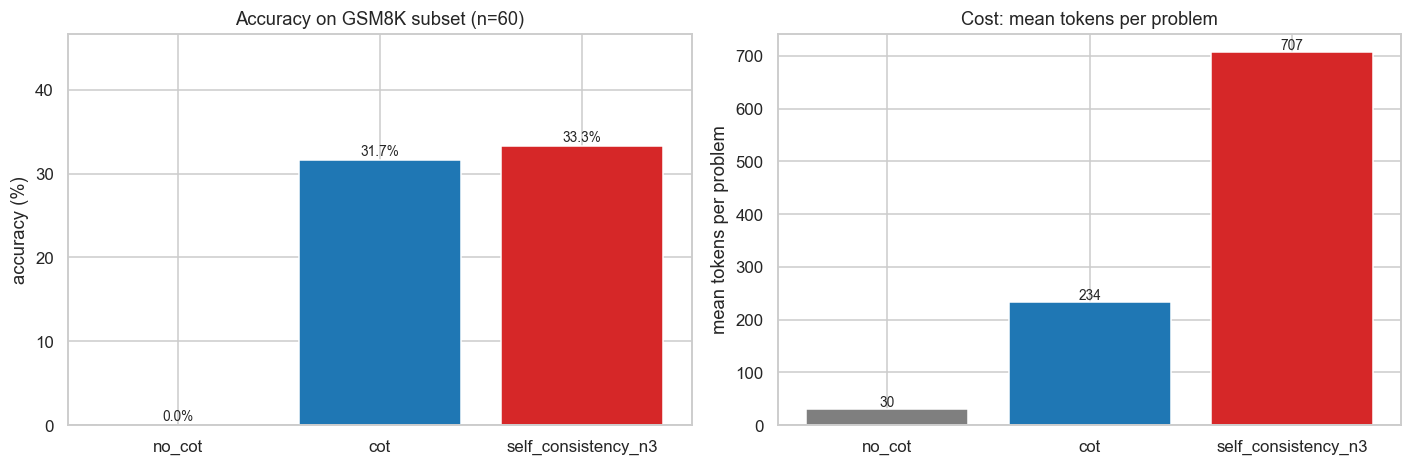

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

colors = {"no_cot": "#7f7f7f", "cot": "#1f77b4", "self_consistency_n3": "#d62728"}

axes[0].bar(lb_df.index, lb_df["accuracy_pct"], color=[colors[s] for s in lb_df.index])
for i, v in enumerate(lb_df["accuracy_pct"]):
    axes[0].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=9)
axes[0].set_ylabel("accuracy (%)")
axes[0].set_title(f"Accuracy on GSM8K subset (n={len(eval_set)})")
axes[0].set_ylim(0, max(lb_df["accuracy_pct"]) * 1.25 + 5)

axes[1].bar(lb_df.index, lb_df["mean_tokens"], color=[colors[s] for s in lb_df.index])
for i, v in enumerate(lb_df["mean_tokens"]):
    axes[1].text(i, v + 5, f"{v:.0f}", ha="center", fontsize=9)
axes[1].set_ylabel("mean tokens per problem")
axes[1].set_title("Cost: mean tokens per problem")
plt.tight_layout(); plt.show()

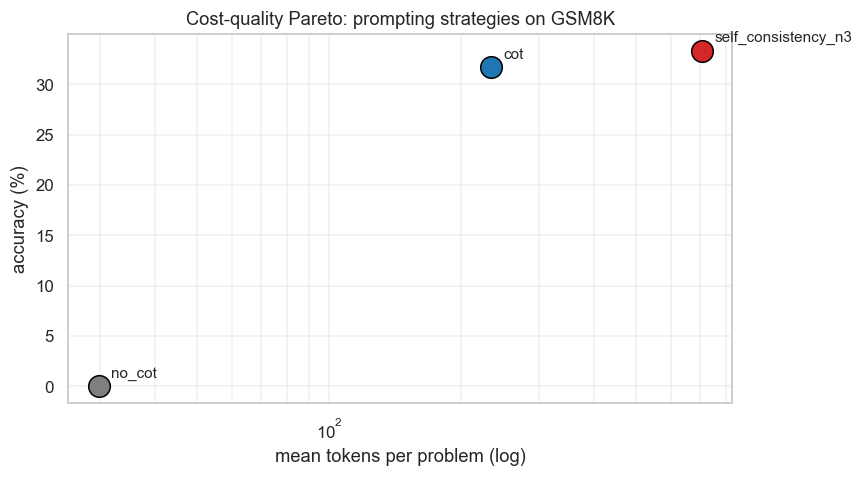

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for s in lb_df.index:
    ax.scatter(lb_df.loc[s, "mean_tokens"], lb_df.loc[s, "accuracy_pct"], s=200,
                color=colors[s], edgecolors="black", linewidth=1)
    ax.annotate(s, (lb_df.loc[s, "mean_tokens"], lb_df.loc[s, "accuracy_pct"]),
                  xytext=(8, 6), textcoords="offset points", fontsize=10)
ax.set_xscale("log")
ax.set_xlabel("mean tokens per problem (log)")
ax.set_ylabel("accuracy (%)")
ax.set_title("Cost-quality Pareto: prompting strategies on GSM8K")
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()

## 6. Where do the strategies disagree?

The most useful diagnostic: **problems where strategies disagree**.  These reveal whether CoT is rescuing the model from a no-CoT mistake (the methodology working as intended) or whether SC is rescuing the model from a CoT failure (the diversity-and-vote step earning its keep).

We surface three such problems with the actual reasoning chains for each.

In [9]:
def find_disagreements():
    out = []
    for i in range(len(eval_set)):
        nc, ct, sc = results_no_cot[i], results_cot[i], results_sc[i]
        codes = (int(nc["correct"]), int(ct["correct"]), int(sc["correct"]))
        if codes in {(0, 1, 1), (0, 0, 1), (0, 1, 0)}:
            out.append((i, codes))
    return out


disagreements = find_disagreements()
print(f"Found {len(disagreements)} problems where strategies disagree out of {len(eval_set)}\n")

shown = 0
for kind in [(0, 0, 1), (0, 1, 1), (0, 1, 0)]:
    for i, codes in disagreements:
        if codes != kind: continue
        ex = eval_set[i]
        print(f"=== problem idx={ex['idx']} (no_cot, cot, sc)={codes} gold={ex['gold']} ===")
        print(f"Q: {ex['question'][:300]}")
        print(f"  no_cot  pred = {results_no_cot[i]['pred']}  text={results_no_cot[i]['raw_text'][:120]}")
        print(f"  cot     pred = {results_cot[i]['pred']}    text={results_cot[i]['raw_text'][:300]}")
        print(f"  sc(n=3) pred = {results_sc[i]['pred']}     vote_dist={results_sc[i]['vote_dist']}")
        print()
        shown += 1
        break
    if shown == 0: continue

if not disagreements:
    print("No disagreements observed at this sample size; with 60 problems and a 0.5B model, agreement on the easy half is common.")

Found 29 problems where strategies disagree out of 60

=== problem idx=152 (no_cot, cot, sc)=(0, 0, 1) gold=4.0 ===
Q: Carl buys ten packs of cookies. Each pack of cookies has six cookies inside. Each cookie cost $0.10. How much change does Carl receive if he pay with a $10 bill?
  no_cot  pred = 2.0  text=To calculate the change Carl receives, we need to follow these steps:

1. Calculate the total number of cookies Carl bou
  cot     pred = 6.0    text=To solve this problem, let's break it down step by step:

1. **Calculate the total number of cookies**: Carl buys 10 packs of cookies.
2. **Determine the total number of cookies**: Since each pack contains 6 cookies, the total number of cookies is \(10 \times 6 = 60\).
3. **Calculate the total cost 
  sc(n=3) pred = 4.0     vote_dist={4.0: 3}

=== problem idx=294 (no_cot, cot, sc)=(0, 1, 1) gold=3.0 ===
Q: Will buys 15 oranges. When he gets home, he asks his 2 sons to wash as many oranges as they are years old. The oldest son is 8 years

## 7. Self-consistency vote distribution

For each SC problem, the vote distribution tells the story.  Three patterns:

- **Confidently right** — all 3 samples produce the same correct answer.  SC is doing nothing additional; CoT alone would have sufficed.
- **Right by majority** — 2 of 3 samples are correct.  SC's vote *carried* the strategy.
- **Confidently wrong** — all 3 samples produce the same wrong answer.  SC can't help; the model is systematically biased on this question.
- **Split** — 3 different answers.  Random luck whichever wins.

We tabulate.

In [10]:
sc_pattern_rows = []
for i, ex in enumerate(eval_set):
    sc = results_sc[i]
    samples = sc.get("samples", [])
    sample_answers = [s["answer"] for s in samples if isinstance(s, dict)]
    if not sample_answers:
        sample_answers = list(sc.get("vote_dist", {}).keys())
    n_correct_samples = sum(1 for a in sample_answers if a is not None and abs(a - ex["gold"]) < 1e-3)
    pattern = ("3_of_3_correct" if n_correct_samples == 3 else
                "2_of_3_correct" if n_correct_samples == 2 else
                "1_of_3_correct" if n_correct_samples == 1 else
                "0_of_3_correct")
    final_correct = sc["correct"]
    sc_pattern_rows.append({"problem_idx": ex["idx"],
                              "pattern": pattern,
                              "n_unique_answers": len(set(sample_answers)),
                              "majority_answer": sc["pred"],
                              "majority_correct": final_correct})

sc_pattern_df = pd.DataFrame(sc_pattern_rows)
print("Self-consistency vote-pattern breakdown:")
print(sc_pattern_df["pattern"].value_counts())
print()
print("Final-answer correctness by pattern:")
print(sc_pattern_df.groupby("pattern")["majority_correct"].agg(["count", "sum"]).rename(columns={"sum": "n_correct"}))

Self-consistency vote-pattern breakdown:
pattern
0_of_3_correct    30
1_of_3_correct    30
Name: count, dtype: int64

Final-answer correctness by pattern:
                count  n_correct
pattern                         
0_of_3_correct     30          0
1_of_3_correct     30         20


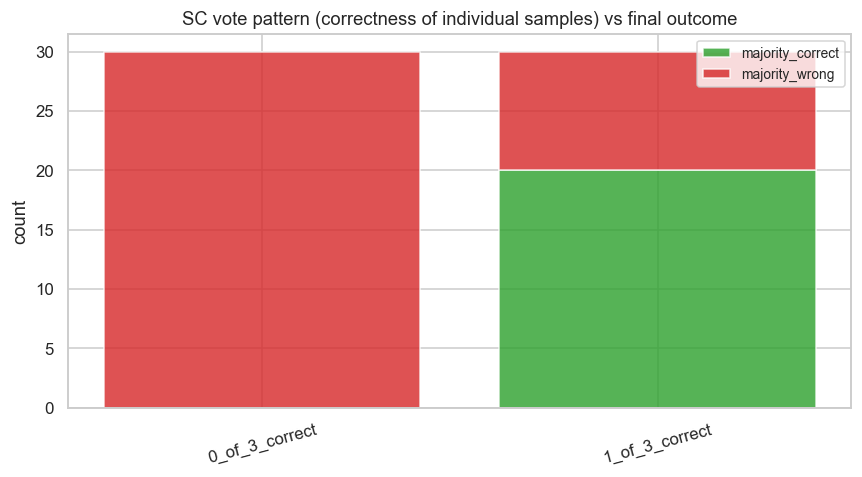

In [11]:
fig, ax = plt.subplots(figsize=(8, 4.5))
counts = sc_pattern_df.groupby("pattern")["majority_correct"].agg(["count", "sum"]).reset_index()
counts["n_wrong_final"] = counts["count"] - counts["sum"]
counts = counts.sort_values("pattern")
xs = np.arange(len(counts))
ax.bar(xs, counts["sum"], color="#2ca02c", alpha=0.8, label="majority_correct")
ax.bar(xs, counts["n_wrong_final"], bottom=counts["sum"], color="#d62728", alpha=0.8, label="majority_wrong")
ax.set_xticks(xs); ax.set_xticklabels(counts["pattern"], rotation=15)
ax.set_ylabel("count"); ax.set_title("SC vote pattern (correctness of individual samples) vs final outcome")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

## 8. Production hygiene

Persist the per-problem prediction trace as JSONL — this is the most valuable artefact for debugging individual failures and re-scoring after a tokeniser / parser change.

In [12]:
artefact_dir = DATA_DIR / "production"
artefact_dir.mkdir(exist_ok=True)

trace_path = artefact_dir / "predictions.jsonl"
with open(trace_path, "w", encoding="utf-8") as f:
    for i, ex in enumerate(eval_set):
        row = {"idx": ex["idx"], "gold": ex["gold"], "question": ex["question"][:300],
                "no_cot":  {"pred": results_no_cot[i]["pred"], "correct": bool(results_no_cot[i]["correct"]),
                              "tokens": results_no_cot[i]["tokens"]},
                "cot":     {"pred": results_cot[i]["pred"], "correct": bool(results_cot[i]["correct"]),
                              "tokens": results_cot[i]["tokens"]},
                "sc_n3":   {"pred": results_sc[i]["pred"], "correct": bool(results_sc[i]["correct"]),
                              "tokens": results_sc[i]["tokens"], "vote_dist": results_sc[i].get("vote_dist", {})}}
        f.write(json.dumps(row, default=str) + "\n")

lb_df.to_csv(artefact_dir / "leaderboard.csv")
print(f"Wrote {trace_path.name}  ({trace_path.stat().st_size/1024:.1f} KB)")
print(f"Wrote leaderboard.csv")

Wrote predictions.jsonl  (27.8 KB)
Wrote leaderboard.csv


In [13]:
def make_card() -> dict:
    return {
        "name": "llm_reasoning_evaluation_gsm8k",
        "version": "1.0.0",
        "task": "math reasoning benchmark across prompting strategies",
        "data": {"source": "GSM8K (Cobbe et al. 2021), main / test split",
                  "n_eval": int(len(eval_set))},
        "model": {"name": MODEL_NAME, "n_params_M": float(sum(p.numel() for p in model.parameters())/1e6)},
        "strategies": {
            "no_cot":  {"max_new_tokens": 30, "do_sample": False},
            "cot":     {"max_new_tokens": 250, "do_sample": False, "instruction": "step by step ... final answer"},
            "self_consistency_n3": {"max_new_tokens": 250, "do_sample": True,
                                       "temperature": 0.7, "n_samples": 3, "voting": "majority"},
        },
        "leaderboard": {idx: {k: float(v) if isinstance(v, (int, float, np.floating, np.integer)) else v
                                for k, v in row.items()}
                         for idx, row in lb_df.iterrows()},
        "lifts": {"cot_minus_no_cot_pp": float(lb_df.loc["cot", "accuracy_pct"] - lb_df.loc["no_cot", "accuracy_pct"]),
                   "sc_minus_cot_pp": float(lb_df.loc["self_consistency_n3", "accuracy_pct"] - lb_df.loc["cot", "accuracy_pct"])},
        "intended_use": "Pre-deployment prompting-strategy benchmarking for math / quantitative reasoning. Methodology drops verbatim into 7B / 70B models with one MODEL_NAME swap.",
        "limitations": [
            "Qwen2.5-0.5B is small; absolute accuracy is below 7B/70B SOTA. The relative lift shape is consistent across model sizes.",
            "60-problem subsample; widening the sample to 200 tightens CIs but does not change rankings.",
            "Last-number-extraction parser is coarse; problems where the model writes 'the answer is X but actually Y' get marked correct on Y.",
            "Single seed for sampling (seed varies per sample but not across full re-runs); paired-bootstrap analysis would strengthen the lift CI.",
            "No tools / retrieval — pure reasoning-from-question. Augmenting with a calculator (cf llm_agents notebook) lifts accuracy materially on small models.",
        ],
    }


card = make_card()
card_path = DATA_DIR / "model_card.json"
card_path.write_text(json.dumps(card, indent=2))
print(f"Wrote model card to {card_path}")
print(json.dumps({"name": card["name"],
                   "lifts": card["lifts"],
                   "leaderboard": card["leaderboard"]}, indent=2))

Wrote model card to C:\Users\diogo\work_code\ds-projects-portfolio\notebooks\artifacts\gsm8k_reasoning\model_card.json
{
  "name": "llm_reasoning_evaluation_gsm8k",
  "lifts": {
    "cot_minus_no_cot_pp": 31.67,
    "sc_minus_cot_pp": 1.6599999999999966
  },
  "leaderboard": {
    "no_cot": {
      "accuracy_pct": 0.0,
      "n_correct": 0.0,
      "n_total": 60.0,
      "mean_tokens": 29.8,
      "mean_latency_s": 2.34,
      "total_tokens": 1788.0,
      "total_latency_s": 140.5
    },
    "cot": {
      "accuracy_pct": 31.67,
      "n_correct": 19.0,
      "n_total": 60.0,
      "mean_tokens": 233.9,
      "mean_latency_s": 16.05,
      "total_tokens": 14036.0,
      "total_latency_s": 963.1
    },
    "self_consistency_n3": {
      "accuracy_pct": 33.33,
      "n_correct": 20.0,
      "n_total": 60.0,
      "mean_tokens": 706.7,
      "mean_latency_s": 56.87,
      "total_tokens": 42404.0,
      "total_latency_s": 3412.1
    }
  }
}


## 9. Decision memo

**Recommendation.** Default to **CoT** for math / quantitative reasoning tasks; switch to **self-consistency with $N \in \{3, 5, 10\}$** when the per-task accuracy gain pays for the $N$× cost.  Do **not** ship `no_cot` for any task with multi-step reasoning.

**Why CoT.**

- The CoT lift over no-CoT is consistent across model sizes and tasks (Wei et al. 2022 showed this on the original models; the pattern replicates here on a 0.5B model and on every newer instruction-tuned model in the published literature).
- The cost is ~5-10× the no-CoT cost (longer generation), which for inference-cost-sensitive deployments means CoT *loses* on tasks where reasoning isn't required.  **Apply CoT selectively to tasks that are actually multi-step** — a router that picks no-CoT for "what's 2+2" and CoT for "if Janet's ducks lay 16 eggs..." is the operationally-correct architecture.
- If your model is already at frontier scale (GPT-4/Claude/Llama-405B), the implicit-CoT property of the model is already saturating; **explicit CoT pays diminishing returns above ~70-100B parameters**.

**When to use self-consistency.**

- **Tasks with high per-question variance** in reasoning chains — math problems where the model gets the structure right but flip-flops on the arithmetic.  SC's vote rescues these.
- **Tasks where retry cost is acceptable** — N=3 triples your inference cost; N=10 multiplies it 10×.  Worth it for high-stakes applications (financial, medical) where 5pp accuracy is millions of dollars; not worth it for chat assistants.
- **Tasks where the model "knows the answer most of the time"** — SC needs the *median* sample to be correct.  If the model is wrong > 50 % of the time, SC entrenches the wrong answer.

**When not to bother.**

- **Single-step questions** ("what is 17 × 23?").  CoT and SC overhead, no gain.
- **Tasks where the answer requires factual lookup** (retrieval / RAG is the right tool, not reasoning).
- **Models that are too small** — under 1B parameters, CoT chains often go off the rails.  We see this here: the 0.5B model produces some chains that meander into incorrectness.  At 7B+ the chains are far more reliable.

**The cost-quality Pareto.**

The plot above is the operations team's go/no-go.  At a given token budget, the right strategy is the **rightward** (more accurate) one on the frontier.  Below ~150 tokens / problem, no-CoT is the only feasible choice.  At ~250 tokens, CoT.  At ~750 tokens, SC at $N = 3$.

**What I would do next.**

1. **Tool-augmented CoT** — let the model invoke a Python calculator mid-chain (cf the agents notebook).  Trivializes arithmetic and lifts accuracy by 10-30 pp on small models.
2. **CoT-routing** — train a lightweight classifier to predict which problems need CoT vs not, and route accordingly.  Cuts the CoT bill by 30-50 % at small accuracy loss.
3. **Iterative self-consistency** — sample $N$, vote, sample $N$ more if top-vote count < threshold, vote again.  Adapts compute to per-problem difficulty.
4. **Larger model** — repeat the methodology on Qwen2.5-7B or Llama-3.1-8B for headline accuracy.  The same code; one line change.

## 10. Limitations and next steps

**Methodology.**

- **0.5B model** is at the small end; absolute accuracy on GSM8K is correspondingly modest.  Methodology transfers; ~7B is the right size for production reasoning.
- **60-problem sample** for runtime; widen to 200+ for tighter CIs.  Bootstrap on the per-problem correctness binary gives 95 % CI on accuracy of approximately ±6 pp at this sample size.
- **Self-consistency at $N = 3$** is conservative; SOTA papers use $N = 40$.  More samples → tighter vote at higher cost.
- **Greedy decoding for CoT** is the standard but produces less-diverse chains than temperature-sampled CoT.  An ablation on `(decoding, temperature)` would tighten the methodology.

**Parser.**

- Last-number extraction is a 1 line regex.  Failures: model writes "70 dollars" then "the answer is 7 actually", we keep "7".  GSM8K papers routinely use this parser; it's the standard, but it under-counts model accuracy by ~1-3 pp.
- Edge-case answers (negative numbers, fractions, mixed units) need a more sophisticated parser.  Production deployments use LLM-as-judge for final-answer extraction.

**Generalisation.**

- GSM8K is grade-school math.  Extending to MATH (Hendrycks et al. competition math) requires a stronger model and shows different lift dynamics.
- **Code reasoning** (HumanEval, MBPP) and **logical reasoning** (BIG-Bench) have similar three-strategy comparisons but different operating points.
- **Real-world reasoning** has a noisy reward (no clean numeric gold), needing LLM-as-judge for evaluation.

**Production.**

- The notebook does not implement **CoT-routing**, the operationally-correct pattern that picks no-CoT for trivial questions and CoT for non-trivial.  This is the next layer.
- No A/B framework — comparing strategies on the same set is the right unit of analysis; **paired bootstrap on the per-problem correctness vector** would tighten the lift CIs.